<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# nac workflow

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [ ]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    leiden_resolution = 1.0
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

adata_path_raw = f"{data_dir}/kb_count_out_nac/counts_unfiltered/adata.h5ad"
adata_types = ["spliced", "unspliced", "ambiguous"]

In [14]:
# !cd {data_dir} && wget https://s3-us-west-2.amazonaws.com/10x.files/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_fastqs.tar && tar -xvf pbmc8k_fastqs.tar
fastqs_sorted = sorted([os.path.join(data_dir, "fastqs", f) for f in os.listdir(os.path.join(data_dir, "fastqs")) if f.endswith(".fastq.gz") and "I1" not in f])
fastqs_sorted = " ".join(fastqs_sorted)

data_dir_parent = os.path.dirname(data_dir)
kb_ref_out_nac = os.path.join(data_dir_parent, "kb_ref_out_nac")
os.makedirs(kb_ref_out_nac, exist_ok=True)
!echo kb ref -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -f1 {kb_ref_out_nac}/f1.fa -f2 {kb_ref_out_nac}/f2.fa -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac -d human
!echo kb count -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -x 10XV2 -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac --h5ad -t {threads} -o {data_dir}/kb_count_out_nac {fastqs_sorted}

kb count -i /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/index.idx -g /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/t2g.txt -x 10XV2 -c1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c1.txt -c2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c2.txt --workflow nac --h5ad -t 32 -o /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/kb_count_out_nac /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L007_R1_001.fastq.gz /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L007_R2_001.fastq.gz /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L008_R1_001.fastq.gz /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L008_R2_001.fastq.gz


## Knee plot - use this output to estimate umi_cutoff

In [ ]:
adata_raw = cs_utils.load_adata(adata_path_raw)
adata_raw.var_names_make_unique()

adata_spliced = adata_raw.copy()
adata_spliced.X = adata_raw.layers["mature"]

adata_unspliced = adata_raw.copy()
adata_unspliced.X = adata_raw.layers["nascent"]

adata_ambiguous = adata_raw.copy()
adata_ambiguous.X = adata_raw.layers["ambiguous"]

adata_dict = {}
adata_dict["raw_spliced"] = adata_spliced
adata_dict["raw_unspliced"] = adata_unspliced
adata_dict["raw_ambiguous"] = adata_ambiguous

UMI cutoff for expected cells (8381): 460.00
UMI cutoff for expected cells (8381): 520.00
UMI cutoff for expected cells (8381): 926.00


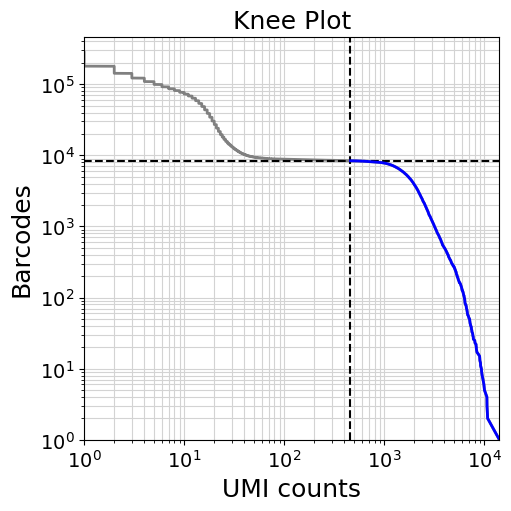

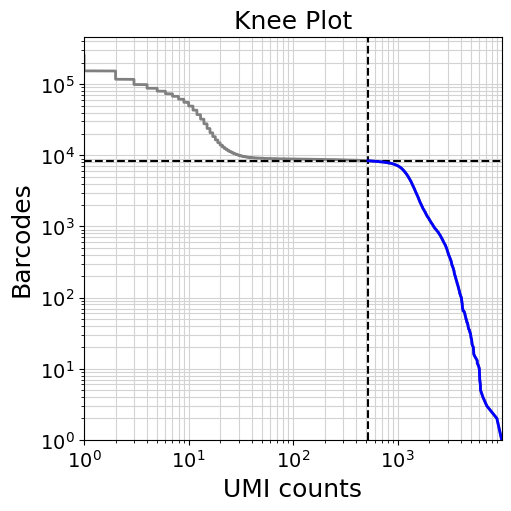

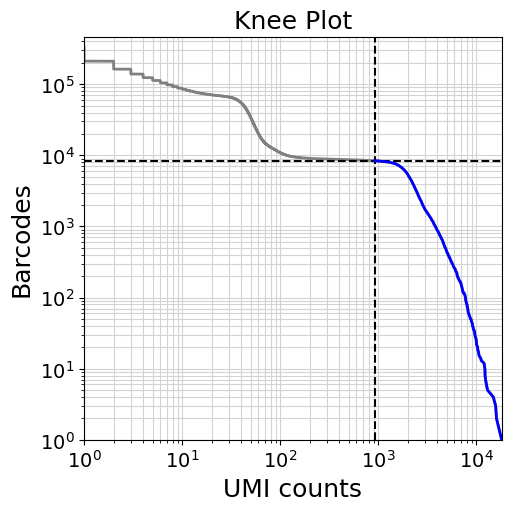

In [ ]:
for adata_name, adata in adata_dict.items():
    expected_cells = 8381
    umi_cutoff = cs_utils.knee_plot(adata, transpose=True, expected_cells=expected_cells, title=adata_name, out_path=os.path.join(out_dir, f"knee_plot_{adata_name}.png"))
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata.var['empty_counts'] = np.array(adata.X[adata.obs['is_empty'].values, :].sum(axis=0)).flatten()
    adata_dict[adata_name] = adata

## cellsweep

In [ ]:
for adata_name, adata in adata_dict.items():
    adata_name_short = adata_name.replace("raw_", "")
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{adata_name_short}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{adata_name_short}.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha=0.9, beta=0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata_cellsweep = cs_utils.load_adata(adata_path_cellsweep, verbose=verbose)
    
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    adata_dict[f"cellsweep_{adata_name_short}"] = adata_cellsweep

## Analysis

### Raw vs cellsweep knee plot, scatterplots

In [ ]:
for adata_name in adata_types:
    adata_raw = adata_dict[f"raw_{adata_name}"]
    adata_cellsweep = adata_dict[f"cellsweep_{adata_name}"]
    
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=[f"raw_{adata_name}", f"cellsweep_{adata_name}"], title=f"Knee Plot {adata_name}", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"cellsweep_knee_plot_{adata_name}.png"))
    cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, f"alpha_hat_histogram_{adata_name}.png"), ylog=True)

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"matrix_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cell_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"gene_expression_scatterplot_{adata_name}.png"), show=True)

## Intron analysis

In [ ]:
for adata_name1, adata_name2 in itertools.combinations(adata_types, 2):
    print(f"Plotting ambient_hat scatterplot: {adata_name1} vs {adata_name2}")
    s = adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"]
    nonzero_min = s[s > 0].min()
    cs_utils.plot_matrix_scatterplot(adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"], adata_dict[f"cellsweep_{adata_name2}"].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=adata_name1, y_axis=adata_name2, out_path=os.path.join(out_dir, f"{adata_name1}_vs_{adata_name2}_ambient_hat_scatterplot.png"), show=True)

In [ ]:
cs_utils.plot_multi_histogram(df1=adata_dict[f"cellsweep_{adata_types[0]}"].obs, df2=adata_dict[f"cellsweep_{adata_types[1]}"].obs, df3=adata_dict[f"cellsweep_{adata_types[2]}"].obs, plotting_column="alpha_hat", df1_name=adata_types[0], df2_name=adata_types[1], df3_name=adata_types[2], out_path=os.path.join(out_dir, "cell_empty_fraction_histogram.png"), show=True)